In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

import yfinance as yf

In [4]:
pfizer = yf.download('PFE', start='2022-01-01', end='2025-01-01')
sunpharma = yf.download('SUNPHARMA.NS', start='2022-01-01', end='2025-01-01')
drreddy = yf.download('DRREDDY.NS', start='2022-01-01', end='2025-01-01')

/tmp/ipykernel_2310/4016670000.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  pfizer = yf.download('PFE', start='2022-01-01', end='2025-01-01')
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2310/4016670000.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sunpharma = yf.download('SUNPHARMA.NS', start='2022-01-01', end='2025-01-01')
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2310/4016670000.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  drreddy = yf.download('DRREDDY.NS', start='2022-01-01', end='2025-01-01')
[*********************100%***********************]  1 of 1 completed


In [5]:
print(pfizer.head())

Price           Close       High        Low       Open    Volume
Ticker            PFE        PFE        PFE        PFE       PFE
Date                                                            
2022-01-03  44.629040  46.125864  44.384820  46.086474  57219200
2022-01-04  42.958893  44.455720  42.494089  44.290282  66993100
2022-01-05  43.825474  44.463592  43.620643  43.990912  52956400
2022-01-06  43.203114  43.825479  42.927384  43.455210  37000400
2022-01-07  43.896385  43.935775  43.037680  43.612776  27703400


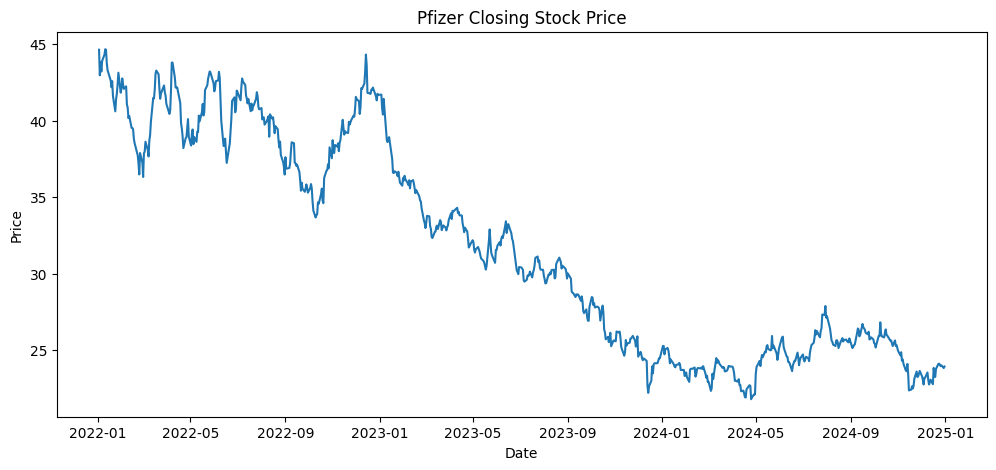

In [6]:
plt.figure(figsize=(12,5))
plt.plot(pfizer['Close'])
plt.title('Pfizer Closing Stock Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

In [7]:
def arima_prediction(data, company_name):

    close_prices = data['Close']

    # Train Test Split
    train_size = int(len(close_prices) * 0.8)

    train = close_prices[:train_size]
    test = close_prices[train_size:]

    # ARIMA Model
    model = ARIMA(train, order=(5,1,0))
    model_fit = model.fit()

    # Prediction
    predictions = model_fit.forecast(steps=len(test))

    # RMSE
    rmse = np.sqrt(mean_squared_error(test, predictions))

    print(f'RMSE for {company_name}:', rmse)

    # Plot
    plt.figure(figsize=(12,5))

    plt.plot(test.index, test.values, label='Actual Price')
    plt.plot(test.index, predictions, label='Predicted Price')

    plt.title(f'{company_name} Stock Prediction using ARIMA')

    plt.xlabel('Date')
    plt.ylabel('Stock Price')

    plt.legend()
    plt.grid(True)
    plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

RMSE for Pfizer: 1.243437760133655


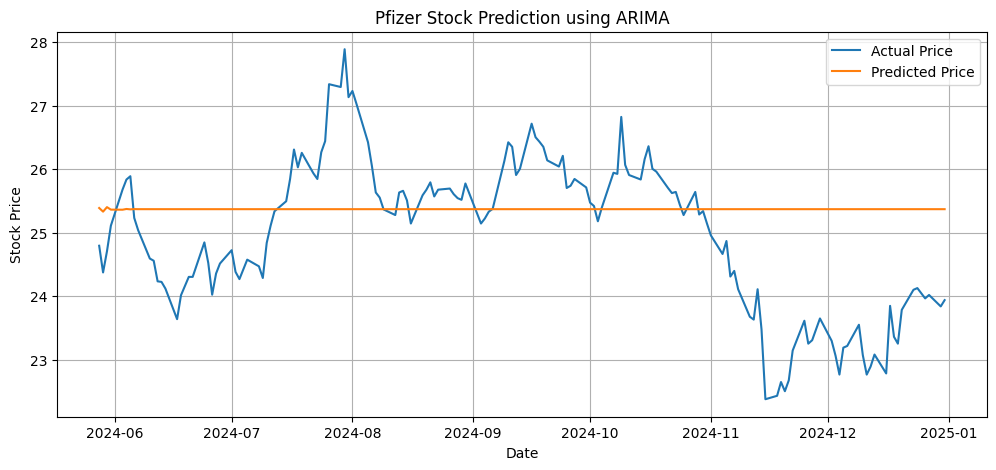

In [8]:
arima_prediction(pfizer, 'Pfizer')

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

RMSE for Sun Pharmaceutical: 316.13762159177867


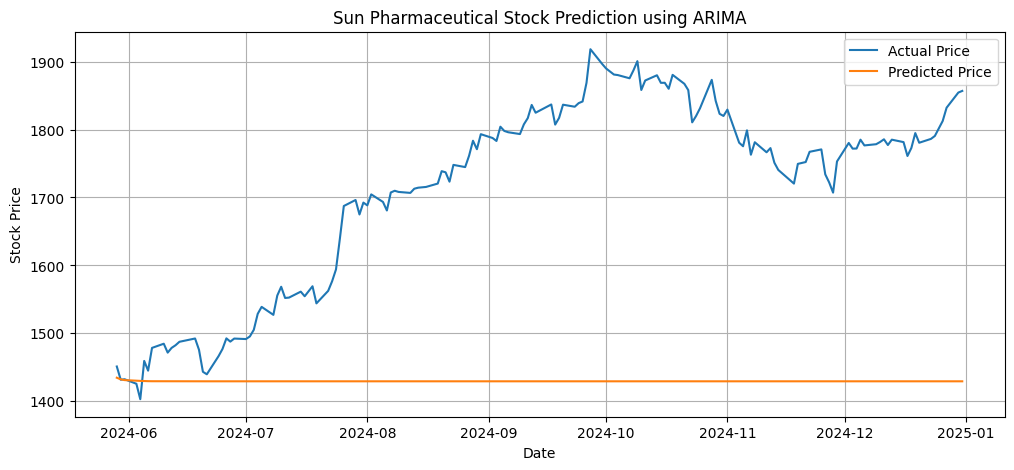

In [9]:
arima_prediction(sunpharma, 'Sun Pharmaceutical')

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

RMSE for Dr. Reddy's Laboratories: 129.6688212435206


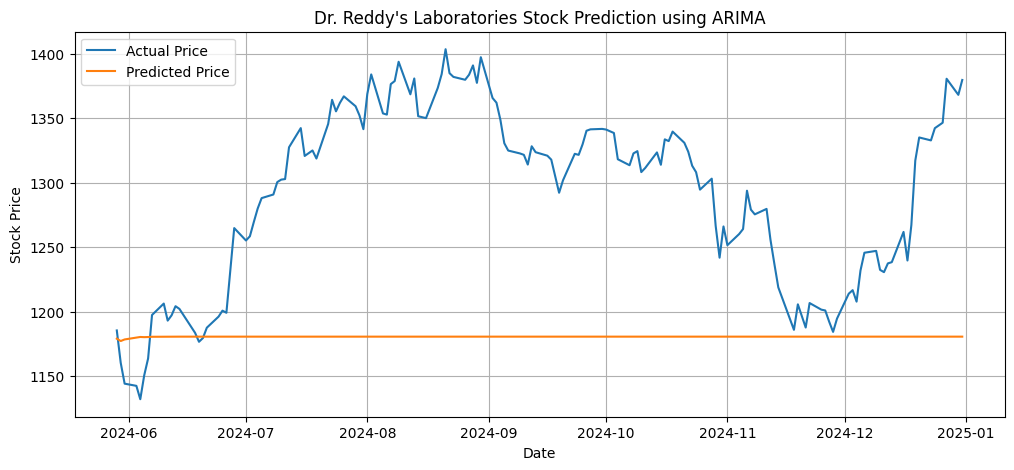

In [10]:
arima_prediction(drreddy, "Dr. Reddy's Laboratories")

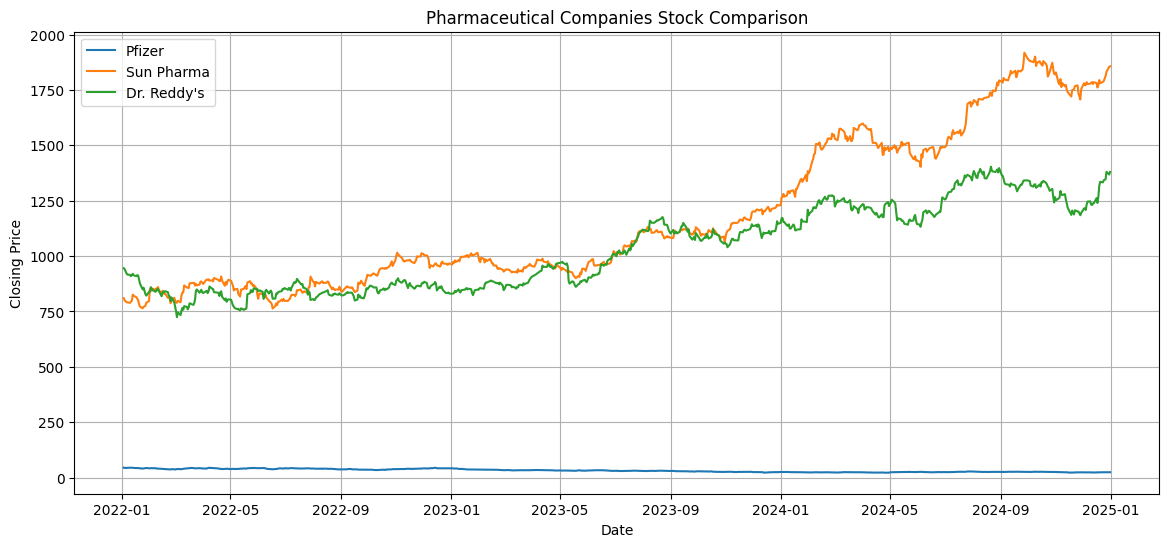

In [11]:
plt.figure(figsize=(14,6))

plt.plot(pfizer['Close'], label='Pfizer')
plt.plot(sunpharma['Close'], label='Sun Pharma')
plt.plot(drreddy['Close'], label="Dr. Reddy's")

plt.title('Pharmaceutical Companies Stock Comparison')
plt.xlabel('Date')
plt.ylabel('Closing Price')

plt.legend()
plt.grid(True)
plt.show()